# 11 · A production nowcasting pipeline: YAML, CLI and snapshots

Research code answers "what is the nowcast?"; production code must also answer
"what was the nowcast last week, with which data and which model, and why did it
change?". Innovation I10 of `nowcastbox` is a **declarative pipeline** (plan §6.2):

* a **YAML spec** describes data, vintage, preprocessing, model and outputs;
* the **CLI** `nowcastbox run spec.yaml` executes it (e.g. from `cron` after each data
  release);
* every run writes a **versioned snapshot** (spec, data hash, nowcast table,
  parameters, density, news against the previous snapshot, HTML report);
* the snapshot history is the **nowcast tracker** of the production system (I6).

> **Status.** The `nowcastbox.pipeline` module and the `run`/`snapshots` commands were
> being finalised in parallel with these notebooks; this notebook follows the spec of
> plan §6.2. If the module is unavailable in your installation, the cells print an
> explanation instead of failing.

In [1]:
import importlib.util
import shutil
import subprocess
import sys
from pathlib import Path

HERE = Path(__file__).resolve().parent if "__file__" in globals() else Path.cwd()
sys.path.insert(0, str(HERE.parent))

import matplotlib.pyplot as plt
import pandas as pd
from utils import OUTPUTS_DIR, display, md, setup, show

import nowcastbox as nb

setup()
PIPELINE = importlib.util.find_spec("nowcastbox.pipeline.runner") is not None
WORKDIR = OUTPUTS_DIR / "11_pipeline"
shutil.rmtree(WORKDIR, ignore_errors=True)  # start from an empty snapshot directory
WORKDIR.mkdir(parents=True)


def cli(*args: str) -> None:
    """Run ``nowcastbox <args>`` in WORKDIR and print its output."""
    if not PIPELINE:
        print(f"[nowcastbox {' '.join(args)}] pipeline module not available in this install")
        return
    cmd = [sys.executable, "-m", "nowcastbox.cli", *args]
    out = subprocess.run(cmd, cwd=WORKDIR, capture_output=True, text=True, check=False)  # noqa: S603
    text = f"{out.stdout}{out.stderr}".replace(str(WORKDIR), ".")  # relative paths
    print(f"$ nowcastbox {' '.join(args)}\n{text}".rstrip())


md(f"Pipeline module available: **{PIPELINE}**; working directory `{WORKDIR.name}/`.")

Pipeline module available: **True**; working directory `11_pipeline/`.

## 1. The spec

The YAML below is the plan's example (§6.2), adapted to a compact panel so the
notebook runs in seconds: the target, the data source (a built-in dataset; CSV/Parquet
files and the BCB/IBGE/IPEA/FRED connectors are also accepted), the information set
(`vintage`), the model with its blocks and the robust/long-run-mean options (I3, I4),
the outputs and the snapshot directory.

In [2]:
SPEC = """\
name: brazil_pib
description: Brazilian GDP (QoQ, SA) - compact panel, blocks, robust EM.
target: pib

data:
  source: brazil_nowcast          # built-in dataset or bcb/ibge/ipea/fred connectors
  columns: [pib, ibc_br, pim_geral, pim_transformacao, pmc_varejo, pmc_ampliado,
            ipca, selic, icbr, credito_saldo_total, focus_pib]
  start: 2005-01
  vintage: today                  # or a date: pseudo real-time information set

preprocessing:
  transform: true                 # legend transformations (qoq, dlog, ...)

model:
  type: MixedFreqDFM
  factors: {global: 1, real: 1, soft: 1}
  idiosyncratic: student_t        # I3
  long_run_mean: time_varying     # I4
  max_iter: 100

outputs: [nowcast, news, density, report_html]
snapshot_dir: ./snapshots
random_state: 0
"""
(WORKDIR / "nowcast_pib.yaml").write_text(SPEC, encoding="utf-8")
cli("validate", "nowcast_pib.yaml")

$ nowcastbox validate nowcast_pib.yaml
OK: nowcast_pib.yaml
  name      : brazil_pib
  target    : pib
  data      : brazil_nowcast (dataset)
  vintage   : today
  model     : MixedFreqDFM (factors={'global': 1, 'real': 1, 'soft': 1})
  outputs   : nowcast, news, density, report_html
  snapshots : ./snapshots


`validate` parses the spec, checks every field (unknown keys, invalid model options,
missing series) and reports errors with their location, without estimating anything.
`nowcastbox init --list` shows the bundled templates (built-in data, CSV files,
connectors, simulated data).

## 2. Three months of production

In production the spec is run after each relevant release. Here we replay the third
quarter of 2026 with three runs, overriding the vintage on the command line
(`--vintage`), as a scheduler would do on 15 July, 15 August and 15 September.

In [3]:
for vintage in ("2026-07-15", "2026-08-15", "2026-09-15"):
    cli("run", "nowcast_pib.yaml", "--vintage", vintage)
    print()

$ nowcastbox run nowcast_pib.yaml --vintage 2026-07-15
Nowcast pipeline 'brazil_pib' (vintage 2026-07-15)
  target      : pib
  data        : brazil_nowcast, 11 series, 2005-01 to 2026-07 (hash f5ba01ffe4bd)
  panel       : 11 series after preprocessing
  model       : MixedFreqDFM (factors={'global': 1, 'real': 1, 'soft': 1}, iterations=87, converged=True)
  nowcast     : 2026Q2 = 0.009158  [68%: 0.00107, 0.01725; 90%: -0.004219, 0.02253]
  snapshot    : ./snapshots/20261001-092410-989601_brazil_pib
  report      : ./snapshots/20261001-092410-989601_brazil_pib/report.html



$ nowcastbox run nowcast_pib.yaml --vintage 2026-08-15
Nowcast pipeline 'brazil_pib' (vintage 2026-08-15)
  target      : pib
  data        : brazil_nowcast, 11 series, 2005-01 to 2026-08 (hash dbdf6eb03d8d)
  panel       : 11 series after preprocessing
  model       : MixedFreqDFM (factors={'global': 1, 'real': 1, 'soft': 1}, iterations=89, converged=True)
  nowcast     : 2026Q2 = 0.005491  [68%: -0.002281, 0.01326; 90%: -0.007365, 0.01835]
  news        : 0.00868 -> 0.005039 against 20261001-092410-989601_brazil_pib (news -0.003643, revisions 1.781e-06, re-estimation 0)
    pim_geral: -0.002915
    pim_transformacao: -0.0006984
    ibc_br: -2.156e-05
    ibc_br: 8.657e-06
    ipca: -7.514e-06
  snapshot    : ./snapshots/20261001-092414-333854_brazil_pib
  report      : ./snapshots/20261001-092414-333854_brazil_pib/report.html



$ nowcastbox run nowcast_pib.yaml --vintage 2026-09-15
Nowcast pipeline 'brazil_pib' (vintage 2026-09-15)
  target      : pib
  data        : brazil_nowcast, 11 series, 2005-01 to 2026-09 (hash 92d44c5139bc)
  panel       : 11 series after preprocessing
  model       : MixedFreqDFM (factors={'global': 1, 'real': 1, 'soft': 1}, iterations=91, converged=True)
  nowcast     : 2026Q3 = -0.0007442  [68%: -0.009832, 0.008343; 90%: -0.01578, 0.01429]
  news        : -9.139e-05 -> -0.0009893 against 20261001-092414-333854_brazil_pib (news -0.0008961, revisions -1.791e-06, re-estimation 0)
    pim_geral: -0.001238
    selic: 0.0002171
    ipca: 0.000167
    pim_transformacao: 4.411e-05
    ibc_br: -3.238e-05
  snapshot    : ./snapshots/20261001-092419-954240_brazil_pib
  report      : ./snapshots/20261001-092419-954240_brazil_pib/report.html



Each run prints the headline nowcast with its 68 %/90 % bands, the snapshot written
and — from the second run on — the **news** against the previous snapshot: the change
of the nowcast split into the effect of new releases, data revisions and
re-estimation, with the largest contributions by series (Bańbura & Modugno, 2014).

## 3. Snapshots

Snapshots are plain directories (`manifest.json` + CSV files + `report.html`), easy to
archive, diff and audit.

In [4]:
cli("snapshots", "list", "snapshots")

$ nowcastbox snapshots list snapshots
                                         name target                          created     vintage         model headline_period  headline     data_hash  report
id                                                                                                                                                             
20261001-092410-989601_brazil_pib  brazil_pib    pib 2026-10-01 09:24:10.989601+00:00  2026-07-15  MixedFreqDFM          2026Q2  0.009158  f5ba01ffe4bd    True
20261001-092414-333854_brazil_pib  brazil_pib    pib 2026-10-01 09:24:14.333854+00:00  2026-08-15  MixedFreqDFM          2026Q2  0.005491  dbdf6eb03d8d    True
20261001-092419-954240_brazil_pib  brazil_pib    pib 2026-10-01 09:24:19.954240+00:00  2026-09-15  MixedFreqDFM          2026Q3 -0.000744  92d44c5139bc    True


In [5]:
cli("snapshots", "diff", "snapshots")

$ nowcastbox snapshots diff snapshots
Snapshot diff 20261001-092414-333854_brazil_pib -> 20261001-092419-954240_brazil_pib
  vintage          : 2026-08-15 -> 2026-09-15
  data changed     : yes
  data cells       : new 11, revised 10, removed 0
  headline change  : 2026Q3 0.000292462 -> -0.000744213 (-0.00103667)
  spec vintage: '2026-08-15' -> '2026-09-15'

               old          new       change
period                                      
2025Q3   0.0073656   0.00731928  -4.6323e-05
2025Q4  0.00112444   0.00107774 -4.67019e-05
2026Q1   0.0114429    0.0113824 -6.05247e-05
2026Q2  0.00549108   0.00539794 -9.31406e-05
2026Q3 0.000292462 -0.000744213  -0.00103667
2026Q4   0.0079791   0.00881609  0.000836991


## 4. The same from Python

The CLI is a thin layer over `nowcastbox.pipeline`: `run_pipeline` accepts a spec file,
a mapping or a `NowcastSpec`, and `SnapshotStore` reads the snapshot directory.

In [6]:
if PIPELINE:
    from nowcastbox.pipeline import NowcastSpec, SnapshotStore, run_pipeline

    spec = NowcastSpec.from_yaml(WORKDIR / "nowcast_pib.yaml")
    run = run_pipeline(  # the 1 October run, from Python: a fourth snapshot
        spec, snapshot_dir=WORKDIR / "snapshots", vintage="2026-10-01"
    )
    print(run.summary().replace(str(WORKDIR), "."))
else:
    print("nowcastbox.pipeline not available: skipped.")

Nowcast pipeline 'brazil_pib' (vintage 2026-10-01)
  target      : pib
  data        : brazil_nowcast, 11 series, 2005-01 to 2026-09 (hash 9b46b1eb10a0)
  panel       : 11 series after preprocessing
  model       : MixedFreqDFM (factors={'global': 1, 'real': 1, 'soft': 1}, iterations=90, converged=True)
  nowcast     : 2026Q3 = -0.000768  [68%: -0.009851, 0.008315; 90%: -0.01579, 0.01426]
  news        : -0.0009771 -> -0.001038 against 20261001-092419-954240_brazil_pib (news -6.066e-05, revisions -7.164e-11, re-estimation 0)
    selic: -6.834e-05
    credito_saldo_total: 7.938e-06
    focus_pib: -2.52e-07
  snapshot    : ./snapshots/20261001-092425-186924_brazil_pib
  report      : ./snapshots/20261001-092425-186924_brazil_pib/report.html


## 5. The production nowcast tracker

The snapshot history is the record of what the system said at each date. For the
third quarter of 2026:

,vintage,period,value
id,,,
20261001-092410-989601_brazil_pib,2026-07-15,2026Q3,0.0066
20261001-092414-333854_brazil_pib,2026-08-15,2026Q3,0.0003
20261001-092419-954240_brazil_pib,2026-09-15,2026Q3,-0.0007
20261001-092425-186924_brazil_pib,2026-10-01,2026Q3,-0.0008


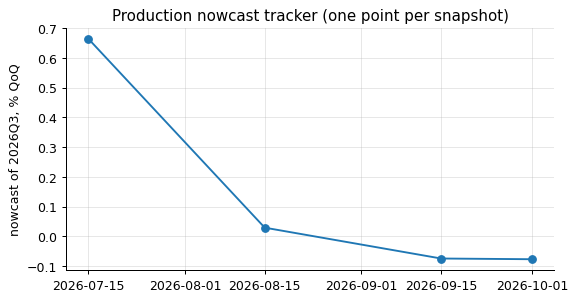

In [7]:
if PIPELINE:
    store = SnapshotStore(WORKDIR / "snapshots")
    history = store.history(period="2026Q3")
    display(history[["vintage", "period", "value"]])
    fig, ax = plt.subplots(figsize=(7, 3.5))
    ax.plot(pd.to_datetime(history["vintage"]), 100 * history["value"], "o-")
    ax.set_ylabel("nowcast of 2026Q3, % QoQ")
    ax.set_title("Production nowcast tracker (one point per snapshot)")
    show(fig, "11_history")

The estimate for 2026Q3 fell from about +0.7 % in mid-July (when the quarter had just
started and the model leaned on its unconditional mean and the Focus survey) to
around zero in mid-September, as the June and July industrial production figures —
the dominant news items in the run logs above — came in weak.

Between snapshots the nowcast can also be tracked **release by release** with the
tracker of notebook 07 (`res.nowcast_tracker(...)`), which the report of each run
includes when the `news` output is requested.

## 6. Scheduling

A typical deployment runs the spec every working day at 9 a.m., after the overnight
releases, and publishes the latest report:

```cron
0 9 * * 1-5  cd /srv/nowcast && nowcastbox run nowcast_pib.yaml --quiet \
             && cp "$(ls -d snapshots/*/ | tail -1)report.html" /var/www/nowcast/index.html
```

With `vintage: today` the information set is whatever the data source returns on that
day; with connectors (`source: bcb`, `ibge`, `ipea`, `fred`) the data are downloaded
and cached; snapshots record the data hash, so any published number can be traced
back to its exact inputs.

### References

* Bańbura, M. & Modugno, M. (2014). *Journal of Applied Econometrics*, 29(1), 133–160.
* Bok, B., Caratelli, D., Giannone, D., Sbordone, A. M. & Tambalotti, A. (2018).
  Macroeconomic nowcasting and forecasting with big data. *Annual Review of
  Economics*, 10, 615–643 (the NY Fed's weekly production cycle).

In [8]:
_ = nb.__version__  # the notebook was executed with this nowcastbox version
md(f"Executed with nowcastbox {nb.__version__}.")

Executed with nowcastbox 0.1.0.dev0.